In [10]:
import numpy as np

def solve_fluxes(xi):
    """
    Solves the system of linear equations for phi_1, phi_2, phi_3, phi_4
    given a specific value of xi.
    
    Equations rearranged for matrix form (A * phi = b):
    1) 2*phi_1 + 0*phi_2 + 0*phi_3 + 2*phi_4 = xi
    2) 0*phi_1 + 1*phi_2 + 1*phi_3 + 2*phi_4 = 1
    3) 6*phi_1 - 5*phi_2 - 8*phi_3 - 2*phi_4 = -12*xi
    4) 1*phi_1 + 2.5*phi_2 + 2*phi_3 - 1*phi_4 = -2*xi
    """
    
    # Coefficient matrix A (coefficients of phi_1, phi_2, phi_3, phi_4)
    A = np.array([
        [2.0, 0.0, 0.0, 2.0],    # Eq 1
        [0.0, 1.0, 1.0, 2.0],    # Eq 2
        [6.0, -5.0, -8.0, -2.0], # Eq 3
        [1.0, 1.0, 1.0, 1.0]    # Eq 4
    ])
    
    # Dependent variable vector b (constants and xi terms)
    b = np.array([
        xi,        # Eq 1 RHS #carbon
        1.0,       # Eq 2 RHS #nitrogen
        -12.0 * xi,# Eq 3 RHS #electron
        1.0  # Eq 4 RHS #sum to one
    ])
    
    try:
        # Solve the linear system
        phi = np.linalg.solve(A, b)
        
        phi_1, phi_2, phi_3, phi_4 = phi
        
        return phi_1, phi_2, phi_3, phi_4
        
    except np.linalg.LinAlgError:
        print(f"Error: The system is singular for xi = {xi}. No unique solution exists.")
        return None



In [12]:
x = np.logspace(-4, 4, 100)
oxid = np.zeros(100)
deni = np.zeros(100)
dnra = np.zeros(100)
anab = np.zeros(100)
for i, x_i in enumerate(x):
    oxid[i], deni[i], dnra[i], anab[i] = solve_fluxes(x_i)
    

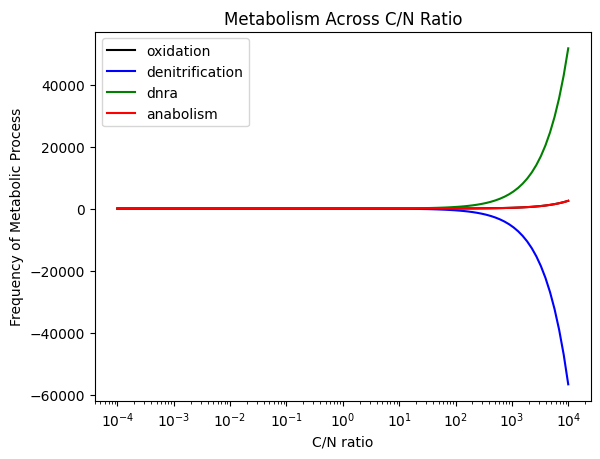

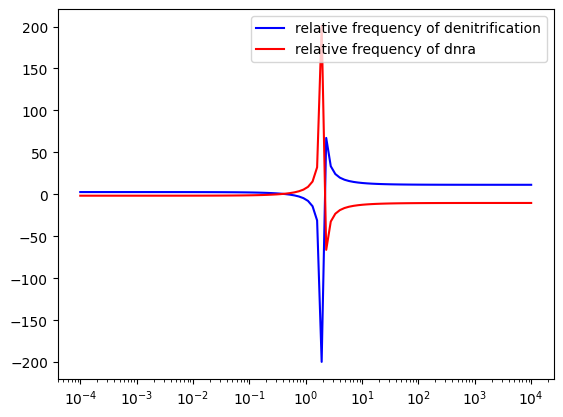

In [13]:
import matplotlib.pyplot as plt

plt.plot(x, oxid, 'Black', label = 'oxidation')
plt.plot(x, deni, 'Blue', label = 'denitrification')
plt.plot(x, dnra, 'Green', label = 'dnra')
plt.plot(x, anab, 'Red', label = 'anabolism')
plt.title('Metabolism Across C/N Ratio')
plt.xlabel('C/N ratio')
plt.ylabel('Frequency of Metabolic Process')
plt.legend()
plt.xscale('log')
plt.show()

plt.plot(x, deni/(deni + dnra), color = 'Blue', label = 'relative frequency of denitrification')
plt.plot(x, dnra/(deni + dnra), color = 'Red', label = 'relative frequency of dnra')
plt.xscale('log')
plt.legend()
plt.show()

### Problem: solutionsa re negative!!! 

Try again, ignoring ATP conservation but enforcicing positivity and maximizing phi_4 (biomass)

In [75]:
import numpy as np

def solve_four_constraints(xi, C):
    """
    Solves 4 equations with 4 unknowns directly.
    Returns [phi_1, phi_2, phi_3, phi_4] if all positive, else None.
    
    Constraints:
    1. 6*phi_1 - 5*phi_2 - 8*phi_3 - 2*phi_4 = -12*xi    (Electron)
    2. phi_1 + 2.5*phi_2 + 2*phi_3 - phi_4 = -2*xi       (ATP)
    3. phi_1 - xi*phi_2 - xi*phi_3 + (1-2*xi)*phi_4 = 0  (Ratio)
    4. phi_1 + phi_4 = C                                  (Sum constraint)
    """
    
    # Coefficient matrix (4x4)
    A = np.array([
        [6.0, -5.0, -8.0, -2.0],              # Eq 3: Electron
        [1.0, 2.5, 2.0, -1.0],                # Eq 4: ATP
        [1.0, -xi, -xi, (1.0 - 2.0*xi)],      # Ratio constraint
        [1.0, 0.0, 0.0, 1.0]                  # Sum: phi_1 + phi_4 = C
    ])
    
    # Right-hand side vector
    b = np.array([
        -12.0 * xi,
        -2.0 * xi,
        0.0,
        C
    ])
    
    try:
        # Solve directly
        phi = np.linalg.solve(A, b)
        
        # Check positivity (all phi >= 0)
        if np.all(phi >= 0):
            return phi
        else:
            return None  # Negative flux = physically impossible
            
    except np.linalg.LinAlgError:
        return None  # Singular matrix = no unique solution

# --- Main Loop ---
if __name__ == "__main__":
    xi = 0.2   # Fixed xi
    C = 100    # Fixed C (phi_1 + phi_4)
    
    phi = solve_four_constraints(xi, C)
    
    if phi is not None:
        print(f"✅ Solution found for xi={xi}, C={C}:")
        print(f"   phi_1 = {phi[0]:.6f}")
        print(f"   phi_2 = {phi[1]:.6f}")
        print(f"   phi_3 = {phi[2]:.6f}")
        print(f"   phi_4 = {phi[3]:.6f}")
        print(f"   Check: phi_1 + phi_4 = {phi[0] + phi[3]:.6f} (should be {C})")
    else:
        print(f"❌ No positive solution for xi={xi}, C={C}")
        print("   Try different xi or C values")
    
    # --- Optional: Scan C to find feasible range for fixed xi ---
    print(f"\n🔍 Scanning C values for xi={xi}...")
    feasible_C = []
    for C_test in np.linspace(0.01, 2.0, 100):
        if solve_four_constraints(xi, C_test) is not None:
            feasible_C.append(C_test)
    
    if feasible_C:
        print(f"   Feasible C range: [{min(feasible_C):.3f}, {max(feasible_C):.3f}]")
    else:
        print(f"   No feasible C in this range!")

❌ No positive solution for xi=0.2, C=100
   Try different xi or C values

🔍 Scanning C values for xi=0.2...
   No feasible C in this range!


In [69]:
x = np.logspace(-4, 4, 100)
oxid = np.zeros(100)
deni = np.zeros(100)
dnra = np.zeros(100)
anab = np.zeros(100)
for i, x_i in enumerate(x):
    oxid[i], deni[i], dnra[i], anab[i] = solve_three_constraints(x_i)
    

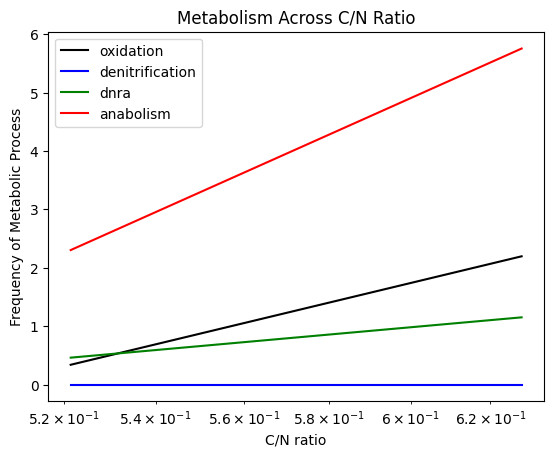

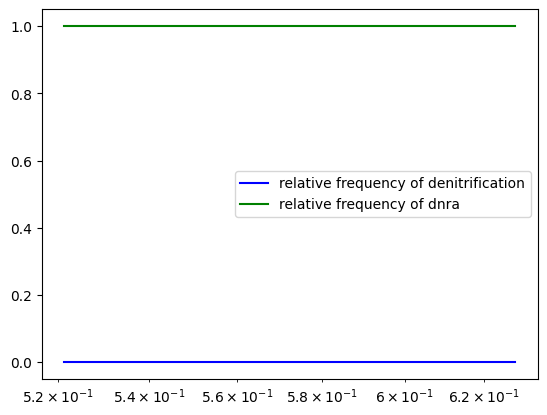

In [73]:
import matplotlib.pyplot as plt

plt.plot(x, oxid, 'Black', label = 'oxidation')
plt.plot(x, deni, 'Blue', label = 'denitrification')
plt.plot(x, dnra, 'Green', label = 'dnra')
plt.plot(x, anab, 'Red', label = 'anabolism')
plt.title('Metabolism Across C/N Ratio')
plt.xlabel('C/N ratio')
plt.ylabel('Frequency of Metabolic Process')
plt.legend()
plt.xscale('log')
plt.show()

plt.plot(x, deni/(deni + dnra), color = 'Blue', label = 'relative frequency of denitrification')
plt.plot(x, dnra/(deni + dnra), color = 'Green', label = 'relative frequency of dnra')
plt.xscale('log')
plt.legend()
plt.show()